# 阶段笔记：从布拉格光栅到收发一体色散引擎
**TFLN 慢光色散器件 × ADC-free 光子 LiDAR** · 2026-09-19 · 对应活笔记 lab-note.ipynb 的体系化整理

**三步走**：轨道 1 均匀光栅（懂物理）→ 轨道 2 啁啾光栅（做器件）→ 轨道 3 激光器融合（成系统）。

阅读地图：
| 部分 | 内容 | 来源章节 |
|---|---|---|
| I | 物理基础：一条公理 + 五层推导 | §0–2, §7–8 |
| II | 色散器件：均匀 → 啁啾，仿真验证 | §3–4 |
| III | 系统构想：收发共用 τ(λ) | §6, §10 |
| IV | 文献坐标与竞争格局 | §5, §11 |
| V | 下一步学习清单 | §9 |

## I. 物理基础

### I.1 组织公理
**本项目的所有物理量都是群折射率 $n_g$ 或其导数。**

| 量 | 表达式 | 角色 |
|---|---|---|
| 调制效率 | $\Delta\phi \propto n_g L$（$V_\pi L \propto 1/n_g$） | 慢光 → 调制增强 |
| 群延迟 | $\tau = n_g L/c$ | 器件的输出量 |
| GVD | $\beta_2 = dn_g/d\omega$ | 色散的物理本质 |
| 色散规格 | $D = d\tau/d\lambda = -\frac{2\pi c}{\lambda^2}\beta_2$ | 系统语言 |
| 损耗惩罚 | $\alpha \propto n_g$ | 慢光的代价 |
| 带宽约束 | $\Delta\omega\cdot\tau \sim$ 常数 | 延迟-带宽积 |

区分：相折射率 $n$（LN≈2.2）决定模式与布拉格条件；群折射率 $n_g$ 决定包络速度与相互作用——**主角是 $n_g$**。

### I.2 光栅为什么有色散（五层推导，结论链）
1. 均匀波导：$n_g$≈常数，无色散。
2. 周期刻纹 $\Lambda$：前/反向模式耦合，布拉格条件 $\lambda_B = 2n_{\rm eff}\Lambda$，失谐 $\delta = 2\pi n_{\rm eff}(1/\lambda - 1/\lambda_B)$，耦合强度 $\kappa$。
3. 本征传播常数（推导见活笔记 §8）：$\beta_\pm = \beta_0 \pm\sqrt{\delta^2-\kappa^2}$；$|\delta|<\kappa$ 为带隙（倏逝区）。
4. 带边 $d\beta/d\omega$ 极值 → $n_g$ 暴涨（慢光）→ $dn_g/d\omega$ 巨大 = 色散。
5. **项目立足点**：相位响应是全周期干涉累加，$\Lambda(z),\kappa(z)$ 光刻可寻址 → **色散设计 = 在空间里雕刻 $\tau(\omega)$**。

## II. 色散器件：仿真验证

### II.1 均匀光栅（轨道 1 收官）
解析式（CMT，分母符号已经 TMM 验证）：
$$r(\delta)=\frac{-i\kappa\sinh(\gamma L)}{\gamma\cosh(\gamma L)+i\delta\sinh(\gamma L)},\quad \gamma=\sqrt{\kappa^2-\delta^2},\quad \tau=-\frac{d\arg r}{d\omega}$$
预期现象：带隙内 $R\to 1$、$\tau\approx 0$（倏逝）；带边外侧慢光区 $\tau$ 鼓包（本仿真 $n_g^{\rm eff}\approx 400$，背景 2.2，**~180× 增强**）；鼓包抖动 = 未 apodize 光栅的**本征 F-P ripple**（ripple 无需相位误差即存在——apodization 的物理起点）。

C:\Users\Administrator\AppData\Local\Temp\ipykernel_38812\1658538077.py:17: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  [a.grid(alpha=.3) for a in ax]; fig.tight_layout(); plt.show()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38812\1658538077.py:17: UserWarning: Glyph 21248 (\N{CJK UNIFIED IDEOGRAPH-5300}) missing from font(s) DejaVu Sans.
  [a.grid(alpha=.3) for a in ax]; fig.tight_layout(); plt.show()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38812\1658538077.py:17: UserWarning: Glyph 20809 (\N{CJK UNIFIED IDEOGRAPH-5149}) missing from font(s) DejaVu Sans.
  [a.grid(alpha=.3) for a in ax]; fig.tight_layout(); plt.show()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38812\1658538077.py:17: UserWarning: Glyph 26629 (\N{CJK UNIFIED IDEOGRAPH-6805}) missing from font(s) DejaVu Sans.
  [a.grid(alpha=.3) for a in ax]; fig.tight_layout(); plt.show()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38812\1658538077

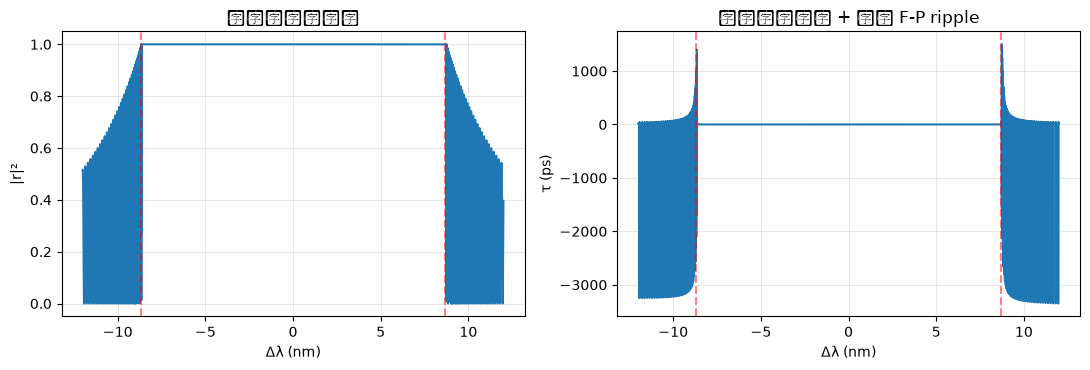

带边 n_g 增强 ≈ 82 ×


In [1]:
import numpy as np, matplotlib.pyplot as plt
n_eff, lam_b, kappa, L = 2.2, 1550e-9, 5e4, 2.5e-3
c = 299792458.0
lam = np.linspace(lam_b-12e-9, lam_b+12e-9, 40001)   # 窗口必须盖过带边(±8.7nm)
delta = 2*np.pi*n_eff*(1/lam - 1/lam_b)
gam = np.sqrt(kappa**2 - delta**2 + 0j)
r = -1j*kappa*np.sinh(gam*L)/(gam*np.cosh(gam*L) + 1j*delta*np.sinh(gam*L))
R = np.abs(r)**2
tau = -np.gradient(np.unwrap(np.angle(r)), 2*np.pi*c/lam)
edge = lam_b**2*kappa/(2*np.pi*n_eff)*1e9
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot((lam-lam_b)*1e9, R); ax[0].set(xlabel='Δλ (nm)', ylabel='|r|²', title='均匀光栅反射谱')
ax[1].plot((lam-lam_b)*1e9, tau*1e12)
for e in (-edge, edge):
    for a in ax: a.axvline(e, color='r', ls='--', alpha=.5)
ax[1].set(xlabel='Δλ (nm)', ylabel='τ (ps)', title='带边慢光鼓包 + 本征 F-P ripple')
[a.grid(alpha=.3) for a in ax]; fig.tight_layout(); plt.show()
print(f'带边 n_g 增强 ≈ {c*tau.max()/L/2.2:.0f} ×')

### II.2 啁啾光栅（轨道 2 当前位置）
物理图像：**每个波长 $\lambda$ 在光栅内"它自己的"位置 $z^*(\lambda)$ 的局域带边被反射**，$\tau(\lambda)=\frac{2}{c}\int_0^{z^*}n_g dz$ → τ 被拉成斜线。
几何估计：$D \approx \frac{2n_g}{cC}$（$C$ = 啁啾率）。数值法：TMM（逐片 2×2 矩阵连乘，边界 $B(L)=0$ → $r=-T_{21}/T_{22}$）。
**有效性判据**：啁啾总量 ≫ 局域带隙 $\Delta\lambda_{\rm gap}=\lambda_B^2\kappa/2\pi n_{\rm eff}$，否则全频段在带隙内、$z^*$ 不动、$D\approx 0$（踩过的坑）。

C:\Users\Administrator\AppData\Local\Temp\ipykernel_38812\2465638277.py:29: UserWarning: Glyph 21825 (\N{CJK UNIFIED IDEOGRAPH-5541}) missing from font(s) DejaVu Sans.
  ax[1].legend(); [a.grid(alpha=.3) for a in ax]; fig.tight_layout(); plt.show()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38812\2465638277.py:29: UserWarning: Glyph 21886 (\N{CJK UNIFIED IDEOGRAPH-557E}) missing from font(s) DejaVu Sans.
  ax[1].legend(); [a.grid(alpha=.3) for a in ax]; fig.tight_layout(); plt.show()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38812\2465638277.py:29: UserWarning: Glyph 20809 (\N{CJK UNIFIED IDEOGRAPH-5149}) missing from font(s) DejaVu Sans.
  ax[1].legend(); [a.grid(alpha=.3) for a in ax]; fig.tight_layout(); plt.show()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_38812\2465638277.py:29: UserWarning: Glyph 26629 (\N{CJK UNIFIED IDEOGRAPH-6805}) missing from font(s) DejaVu Sans.
  ax[1].legend(); [a.grid(alpha=.3) for a in ax]; fig.tight_layout(); plt.show()
C:\U

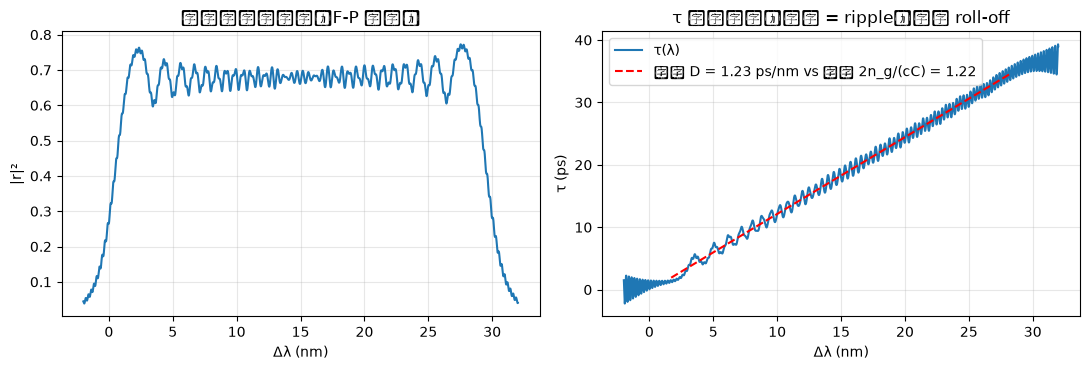

In [2]:
# 线性啁啾光栅 TMM：κ=50/cm, 啁啾 30nm / 2.5mm（局域带隙 0.85nm ≪ 30nm，判据满足）
n_eff, lam_b0, L, kappa = 2.2, 1535e-9, 2.5e-3, 5e3
chirp_nm = 30.0; C = chirp_nm*1e-9/L
N = 800; dz = L/N
lam_b = lam_b0 + C*np.linspace(0, L, N)
lam = np.linspace(lam_b0-2e-9, lam_b0+(chirp_nm+2)*1e-9, 8001)
r = np.empty(len(lam), complex)
for i, l in enumerate(lam):
    d = 2*np.pi*n_eff*(1/l - 1/lam_b)
    g = np.sqrt(kappa**2 - d**2 + 0j)
    s, ch = np.sinh(g*dz)/g, np.cosh(g*dz)
    a11,a12,a21,a22 = ch-1j*d*s, -1j*kappa*s, 1j*kappa*s, ch+1j*d*s
    t11,t12,t21,t22 = 1+0j,0j,0j,1+0j
    for j in range(N):
        t11,t12,t21,t22 = (a11[j]*t11+a12[j]*t21, a11[j]*t12+a12[j]*t22,
                           a21[j]*t11+a22[j]*t21, a21[j]*t12+a22[j]*t22)
    r[i] = -t21/t22
R = np.abs(r)**2
tau = -np.gradient(np.unwrap(np.angle(r)), 2*np.pi*c/lam)
gap = lam_b0**2*kappa/(2*np.pi*n_eff)*1e9
band = (lam > lam_b0+2*gap*1e-9) & (lam < lam_b0+(chirp_nm-2*gap)*1e-9) & (R > 0.5)
p = np.polyfit((lam[band]-lam_b0)*1e9, tau[band]*1e12, 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot((lam-lam_b0)*1e9, R); ax[0].set(xlabel='Δλ (nm)', ylabel='|r|²', title='啁啾光栅反射谱（F-P 起伏）')
ax[1].plot((lam-lam_b0)*1e9, tau*1e12, label='τ(λ)')
ax[1].plot((lam[band]-lam_b0)*1e9, np.polyval(p,(lam[band]-lam_b0)*1e9), 'r--',
           label=f'拟合 D = {p[0]:.2f} ps/nm vs 几何 2n_g/(cC) = {2*n_eff/(c*C)*1e3:.2f}')
ax[1].set(xlabel='Δλ (nm)', ylabel='τ (ps)', title='τ 拉成斜线；抖动 = ripple；两端 roll-off')
ax[1].legend(); [a.grid(alpha=.3) for a in ax]; fig.tight_layout(); plt.show()

**仿真结论**：$D_{\rm sim}=1.23$ ps/nm vs 几何估计 $1.22$ ps/nm——弱耦合（$\kappa L=12.5$）下几何图像足够准；慢光增强因子 >1 的区域（强耦合/带边逼近）待 κ 扫描定量。
**设计三教训**：① 仿真窗口要盖过带边；② ripple 与反射率起伏互为表里（端面 F-P）；③ 有效带宽 ≈ 啁啾总量 − 2Δλ_gap（端头 S 形 roll-off）。

## III. 系统构想：收发共用 $\tau(\lambda)$（轨道 3）

**一句话**：同一 $\tau(\lambda)$ 设计文件用两次——接收端做被动匹配滤波（主线，ADC-free）；发射端用于激光器腔内/腔边（"发射即成型"）。锁钥同锉，chirp 的产生与消除全部发生在光子域。

**与课题组（Yating Wan 组）的接口**：QD 锁模光源 → 色散压缩前端（本项目）→ reservoir 读出（她的硬件）；平台用 300 mm 异质集成产线，TFLN 加工走 Cheng Wang 组渠道。

**三处物理边界**（讨论时主动陈述）：
1. 光栅是 LTI 器件——**塑形** chirp 而非**制造** chirp；chirp 来自增益动力学（DFB 电流调谐/增益开关）或电光调制（time lens）；
2. 反射光栅 + 激光器 = 反馈风险；对策：斜切端面 / 模式转换读写 / 自注入锁定（文献已见先例）；
3. 腔内功率高一个量级 → 光折变损伤需核算；务实路线为腔外紧邻（extended cavity）。

## IV. 文献坐标（数字背下来，讨论直接用）

| 坐标 | 数值 | 出处 |
|---|---|---|
| TFLN 片上基准 | 1.62 ps/nm / 2.5 mm / 29 nm 带宽 / 0.033 dB/mm | [Yu et al., Nature 612, 252 (2022)](https://www.nature.com/articles/s41586-022-05345-1) ✔已核实 |
| SiN 天花板 | 米级 spiral，10 ns 群延迟，>10 nm，30 mm²（0.3 dB/m） | [Geng/Tong et al., arXiv:2604.12564 (2026)](https://arxiv.org/html/2604.12564v1) |
| SiN 早期 | −156.5 ps/nm，1440 ps | Du et al., APL Photonics 5, 101302 (2020) |
| 光纤商用 | 10–1000 ps/nm | 概念书 §3 |
| DFB×TFLN 集成 | 倒装 / 晶圆键合 / 光子引线三条路线 | [Hybrid LN external cavity laser review (2024)](https://pmc.ncbi.nlm.nih.gov/articles/PMC11432941/) |
| ADC-free 相干接收 | 全光相干脉冲压缩（扫频激光器） | Billault et al. (2021)（精读候选） |

**竞争判断**：轨道 2 单靠色散数值赢不了 SiN；**TFLN 差异化 = 电光可调 + 收发共用（轨道 3）**。品质因数建议采用 **DBP（色散-带宽积）**（借自 Geng 2026）。

## V. 下一步学习清单（按优先级）
- **A1** 脉冲压缩定量数学：匹配滤波、时宽带宽积、残余相位→旁瓣推导（口诀已会：ripple 容差 ≈ 0.5/2πB）
- **A2** CMT 出身：麦克斯韦方程 → 模式展开 → 缓变包络；κ 的重叠积分
- **A3** TMM 边界条件推导（r = −T21/T22）
- B 级：apodization 理论 / 慢光损耗标度 / 热光漂移 / GD 计量学
- C 级：LiDAR 链路预算 / 厘米级架构（spiral、cascaded、拼接缝）/ 文献精读（Geng 2026、Billault 2021、apodized TFLN grating 2024）
- 仿真：03 κ 扫描（慢光增强因子何时 >1）→ apodization → 与 Yu 2022 数字逐项对标

---
*活笔记（lab-note.ipynb）持续生长；本阶段笔记每完成一个阶段重建一次。*